# Lab 1: EMG Signal Analysis

Basics of signal analysis with python

## Libraries
The following libraries are the "bread and butter" of data analysis in python

In [8]:
import pandas as pd # Tabular data
import numpy as np # Working with Arrays
import scipy # Scientific computation
import scipy.signal 
import matplotlib.pyplot as plt # Plotting Data

## Working with files using `os` library

the `os` library, "operating system", allows for interaction with the operating system such as reading and writing to files.

In [ ]:
# import os
# #directory = 'Data/'
# file_name = 'D:/Drive D Data/Post_Doc_RIT/Spring 2025/bio robotics lab/Biorobotics_lab_1-main/Data/p18_emg.csv' # Add file name here
# emg_df = pd.read_csv(file_name) # Read the CSV file into a pandas dataframe
# emg_df.columns = emg_df.columns.str.replace(' ','') # Replace the spaces in the column titles for easier handling

NameError: name 'pd' is not defined

In [5]:
import os
import pandas as pd

directory = 'D:/Drive D Data/Post_Doc_RIT/Spring 2025/bio robotics lab/Biorobotics_lab_1-main/Data/'  
file_name = 'p18_emg.csv'  # Only the file name

emg_df = pd.read_csv(os.path.join(directory, file_name))  # Join paths properly
emg_df.columns = emg_df.columns.str.replace(' ', '') 

In [6]:
# Display the data frame preview
display(emg_df)

,DeviceID,Warm?,Sync,Arm,Timestamp,Orientation_W,Orientation_X,Orientation_Y,Orientation_Z,Acc_X,...,EMG_4,EMG_5,EMG_6,EMG_7,EMG_8,Locked,RSSI,Roll,Pitch,Yaw
0,2291479052128,warm,True,left,2019-02-14 14:46:53 744402,-0.514465,-0.485779,0.287659,-0.645508,1.326660,...,-2,1,-1,1,-1,False,0,0.398451,-1.233521,1.567341
1,2291479052128,warm,True,left,2019-02-14 14:46:53 744402,-0.514465,-0.485779,0.287659,-0.645508,1.326660,...,-3,-1,1,0,0,False,0,0.398451,-1.233521,1.567341
2,2291479052128,warm,True,left,2019-02-14 14:46:53 752382,-0.514465,-0.485779,0.287659,-0.645508,1.326660,...,0,-1,-2,1,-1,False,0,0.398451,-1.233521,1.567341
3,2291479052128,warm,True,left,2019-02-14 14:46:53 752382,-0.514465,-0.485779,0.287659,-0.645508,1.326660,...,0,0,-1,-2,-1,False,0,0.398451,-1.233521,1.567341
4,2291479052128,warm,True,left,2019-02-14 14:46:53 756350,-0.519470,-0.484497,0.291138,-0.640930,1.186035,...,0,2,-1,1,1,False,0,0.420894,-1.246889,1.542884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569135,2291479052352,True,False,unknown,2019-02-14 16:14:04 919846,0.176941,0.678650,-0.692627,0.168640,0.981934,...,2,2,-3,0,4,False,0,2.853115,-1.549873,-2.360197
1569136,2291479052352,True,False,unknown,2019-02-14 16:14:04 926902,0.176941,0.678650,-0.692627,0.168640,0.981934,...,0,1,1,-2,-3,False,0,2.853115,-1.549873,-2.360197
1569137,2291479052352,True,False,unknown,2019-02-14 16:14:04 926902,0.176941,0.678650,-0.692627,0.168640,0.981934,...,4,5,-1,0,2,False,0,2.853115,-1.549873,-2.360197
1569138,2291479052352,True,False,unknown,2019-02-14 16:14:04 941786,0.174622,0.678345,-0.693115,0.170166,0.985352,...,-4,-7,-4,-1,-2,False,0,3.094938,-1.549416,-2.602545


## Plotting data

Previewing tabular data is nice, but does not give insight into the data itself. Large datasets can have thousands of lines and real data measurements will be very intensive (this data is 1,405,884 rows) which is unreasonable to review in a tabular method. To view the data, `matplotlib` library will be used to plot mVolts measurement vs Time.

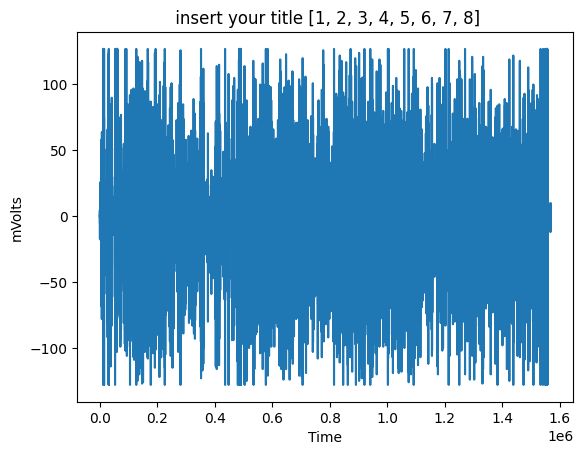

In [ ]:
# channel = [x for x in range(1,9)] # Create channel variables to be used

# plt.figure()
# ax = emg_df['EMG_'+str(channel[0])].plot()
# plt.title(' insert your title ' + str(channel))
# plt.ylabel('mVolts')
# plt.xlabel('Time')
# plt.show()


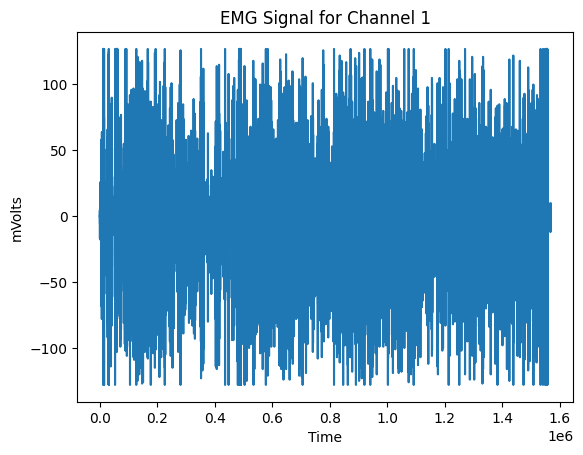

In [10]:
# Define channel numbers
channel = [x for x in range(1, 9)]  # Generates [1,2,3,4,5,6,7,8]

# Ensure column names are formatted correctly
column_name = f'EMG_{channel[0]}'  # Example: 'EMG_1'

# Check if the column exists
if column_name in emg_df.columns:
    plt.figure()
    ax = emg_df[column_name].plot()
    plt.title(f'EMG Signal for Channel {channel[0]}')
    plt.ylabel('mVolts')
    plt.xlabel('Time')
    plt.show()
else:
    print(f"Column '{column_name}' not found in DataFrame!")

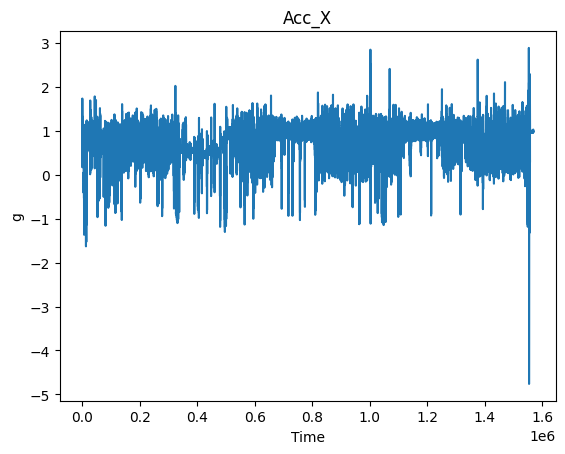

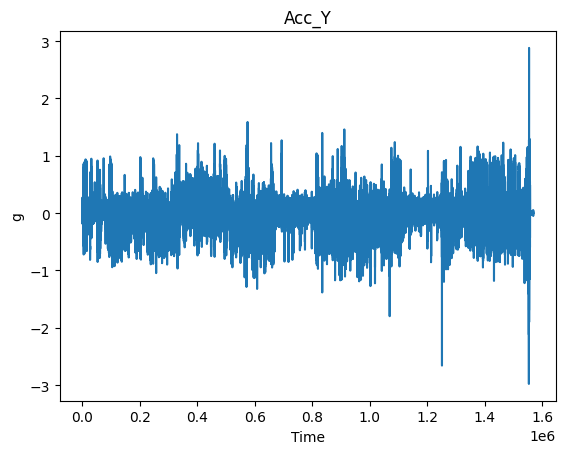

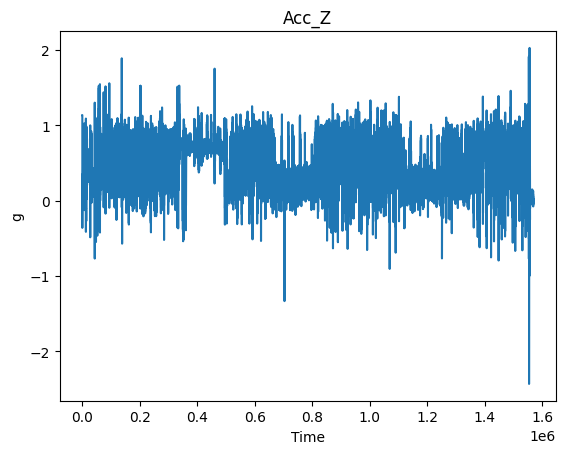

In [11]:
# Plotting multiple channels at once

for channel in ['X','Y','Z']:
    plt.figure()
    emg_df['Acc_'+channel].plot()
    plt.title('Acc_'+str(channel))
    plt.ylabel('g')
    plt.xlabel('Time')
    plt.show()

,DeviceID,Warm?,Sync,Arm,Timestamp,Orientation_W,Orientation_X,Orientation_Y,Orientation_Z,Acc_X,...,EMG_4,EMG_5,EMG_6,EMG_7,EMG_8,Locked,RSSI,Roll,Pitch,Yaw
0,2291479052128,warm,True,left,2019-02-14 14:46:53 744402,-0.514465,-0.485779,0.287659,-0.645508,1.326660,...,2,1,1,1,1,False,0,0.398451,-1.233521,1.567341
1,2291479052128,warm,True,left,2019-02-14 14:46:53 744402,-0.514465,-0.485779,0.287659,-0.645508,1.326660,...,3,1,1,0,0,False,0,0.398451,-1.233521,1.567341
2,2291479052128,warm,True,left,2019-02-14 14:46:53 752382,-0.514465,-0.485779,0.287659,-0.645508,1.326660,...,0,1,2,1,1,False,0,0.398451,-1.233521,1.567341
3,2291479052128,warm,True,left,2019-02-14 14:46:53 752382,-0.514465,-0.485779,0.287659,-0.645508,1.326660,...,0,0,1,2,1,False,0,0.398451,-1.233521,1.567341
4,2291479052128,warm,True,left,2019-02-14 14:46:53 756350,-0.519470,-0.484497,0.291138,-0.640930,1.186035,...,0,2,1,1,1,False,0,0.420894,-1.246889,1.542884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1569135,2291479052352,True,False,unknown,2019-02-14 16:14:04 919846,0.176941,0.678650,-0.692627,0.168640,0.981934,...,2,2,3,0,4,False,0,2.853115,-1.549873,-2.360197
1569136,2291479052352,True,False,unknown,2019-02-14 16:14:04 926902,0.176941,0.678650,-0.692627,0.168640,0.981934,...,0,1,1,2,3,False,0,2.853115,-1.549873,-2.360197
1569137,2291479052352,True,False,unknown,2019-02-14 16:14:04 926902,0.176941,0.678650,-0.692627,0.168640,0.981934,...,4,5,1,0,2,False,0,2.853115,-1.549873,-2.360197
1569138,2291479052352,True,False,unknown,2019-02-14 16:14:04 941786,0.174622,0.678345,-0.693115,0.170166,0.985352,...,4,7,4,1,2,False,0,3.094938,-1.549416,-2.602545


C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


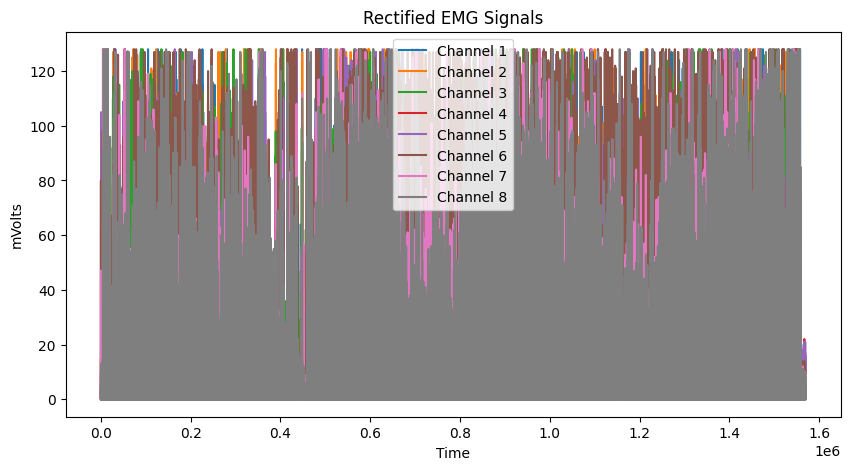

In [ ]:
rectified_signal_df = emg_df.copy() # Copy the original dataframe to avoid overwriting or making changes to it

for col in ['EMG_'+str(i) for i in range(1,9)]:
    rectified_signal_df[col] = rectified_signal_df[col].apply(abs) # Get the absolute value for all the channels

#display(rectified_signal_df)
plt.figure(figsize=(10,5))
for i in range(1, 9):  # Loop over channels 1 to 8
    plt.plot(rectified_signal_df['EMG_'+str(i)], label=f'Channel {i}')

plt.title("Rectified EMG Signals")
plt.xlabel("Time")
plt.ylabel("mVolts")
plt.legend()
plt.show()

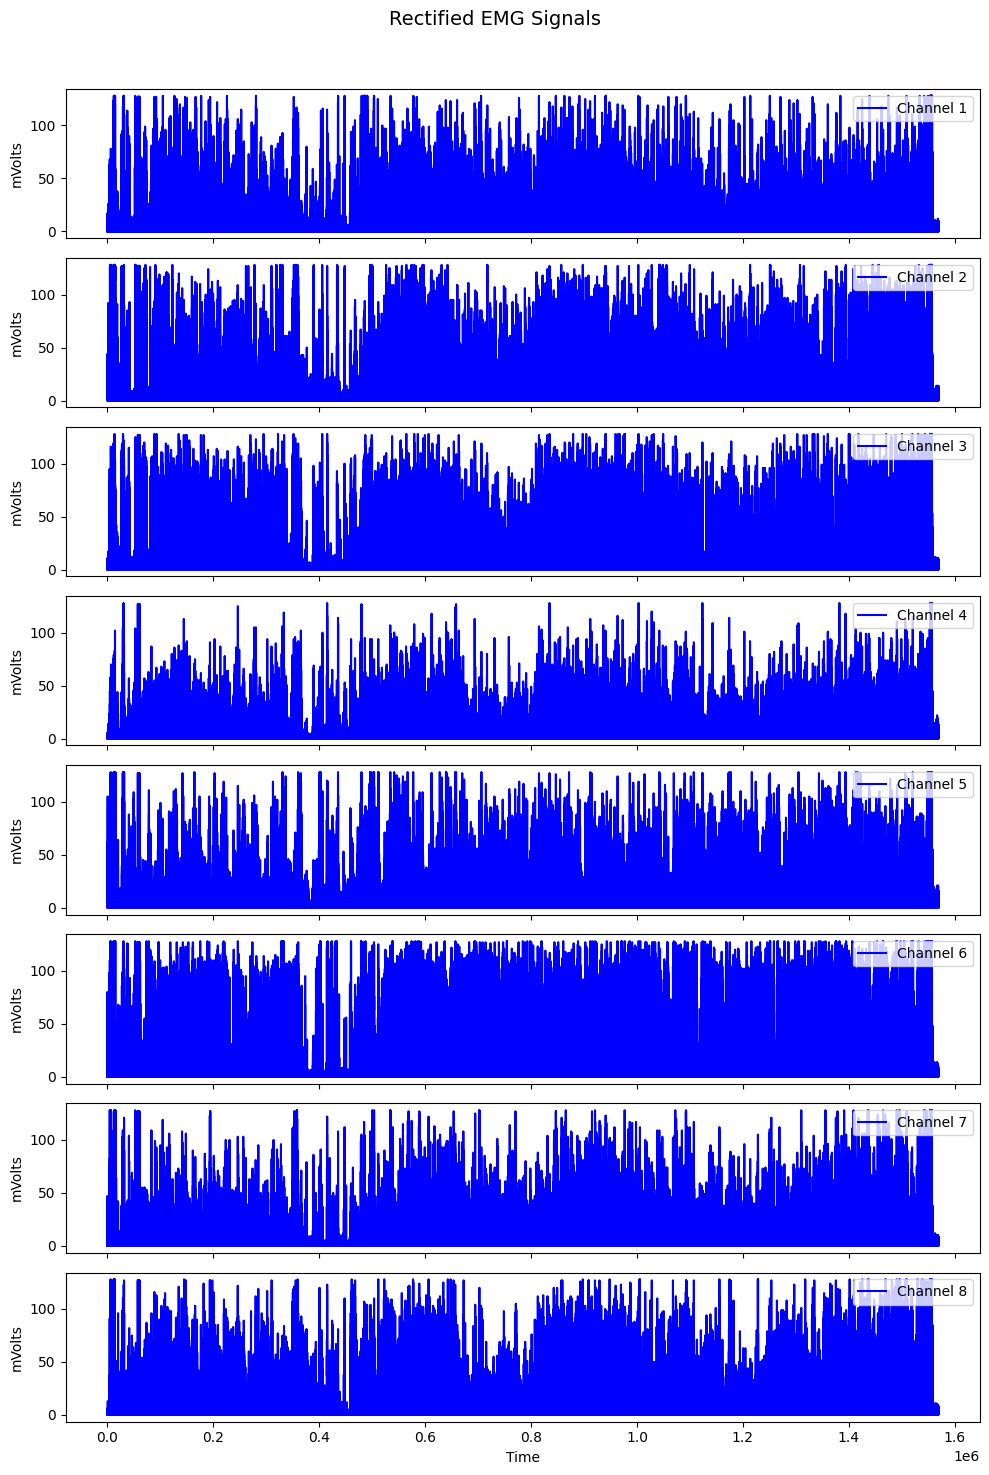

In [14]:
import matplotlib.pyplot as plt

# Create a figure with 8 subplots (one for each EMG channel)
fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(10, 15), sharex=True)

for i, ax in enumerate(axes, start=1):
    ax.plot(rectified_signal_df['EMG_'+str(i)], label=f'Channel {i}', color='b')
    ax.set_ylabel('mVolts')
    ax.legend(loc='upper right')

# Add common labels
plt.xlabel("Time")
fig.suptitle("Rectified EMG Signals", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title

plt.show()